In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

!pip install ucimlrepo

  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
Using cached certifi-2026.2.25-py3-none-any.whl (153 kB)

   -------------------- ------------------- 1/2 [ucimlrepo]
   ---------------------------------------- 2/2 [ucimlrepo]




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from ucimlrepo import fetch_ucirepo

adult = fetch_ucirepo(id=2)
X = adult.data.features
y = adult.data.targets

In [6]:
X.info()
X.head()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       47879 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      47876 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48568 non-null  str  
dtypes: int64(6), str(8)
memory usage: 5.2 MB


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [7]:
X.isnull().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
dtype: int64

In [8]:
X[['education', 'education-num']].drop_duplicates().sort_values('education-num')

,education,education-num
224,Preschool,1
160,1st-4th,2
56,5th-6th,3
15,7th-8th,4
6,9th,5
77,10th,6
3,11th,7
415,12th,8
2,HS-grad,9
10,Some-college,10


In [9]:
y['income'] = y['income'].str.strip('.')
y.value_counts()

income
<=50K     37155
>50K      11687
Name: count, dtype: int64

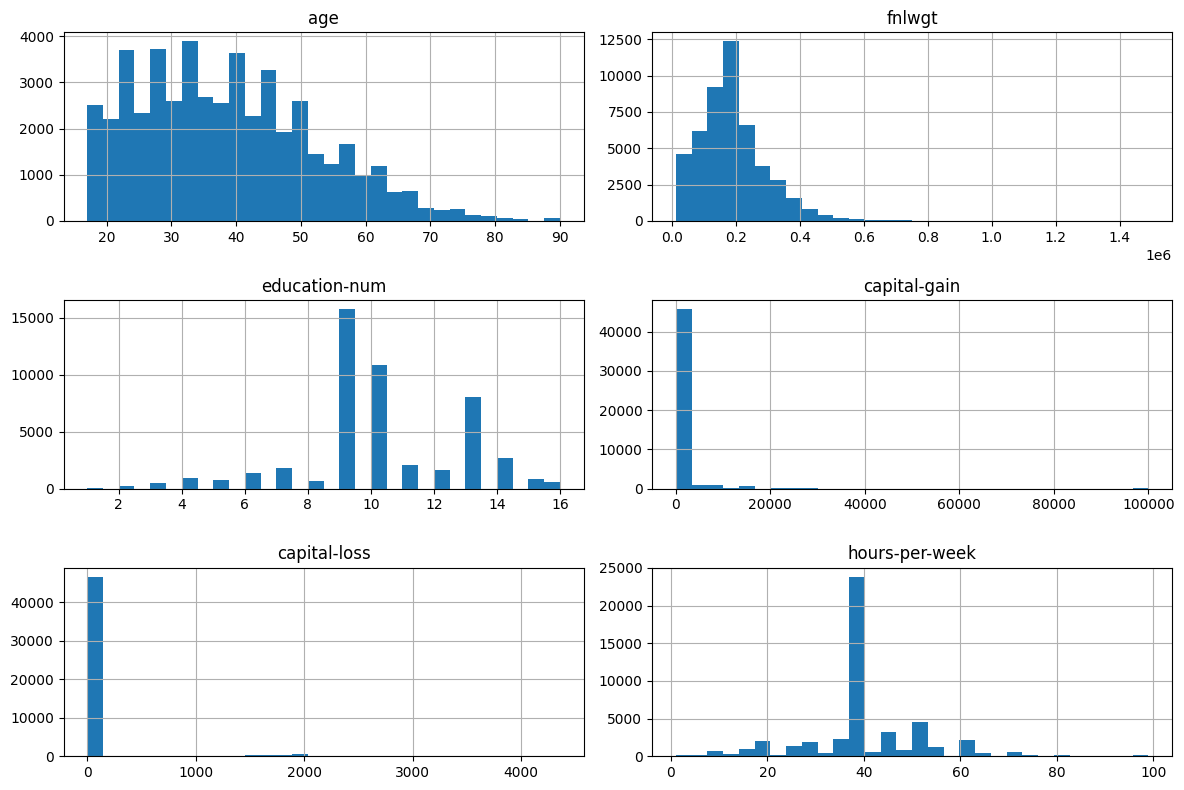

In [10]:
X[["age","fnlwgt","education-num","capital-gain","capital-loss","hours-per-week"]].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()


In [11]:
X = X.drop('education', axis=1)

In [12]:
X.head()

,age,workclass,fnlwgt,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [13]:
from sklearn.model_selection import train_test_split

# Första split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Andra split: dela temp i 50/50 = 10% val, 10% test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [14]:
print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 39073, Val: 4884, Test: 4885


In [15]:
X_train['workclass'].mode()[0]

'Private'

In [16]:
# Beräkna mode från train
workclass_mode = X_train['workclass'].mode()[0]
occupation_mode = X_train['occupation'].mode()[0]
country_mode = X_train['native-country'].mode()[0]

# Fylla in för alla tre seten
for X_set in [X_train, X_val, X_test]:
    X_set['workclass'].fillna(workclass_mode, inplace=True)
    X_set['occupation'].fillna(occupation_mode, inplace=True)
    X_set['native-country'].fillna(country_mode, inplace=True)

C:\Users\pibu_\AppData\Local\Temp\ipykernel_4524\295016119.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  X_set['workclass'].fillna(workclass_mode, inplace=True)
C:\Users\pibu_\AppData\Local\Temp\ipykernel_4524\295016119.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignm

In [17]:
X_train.isnull().sum()

age                 0
workclass         772
fnlwgt              0
education-num       0
marital-status      0
occupation        774
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    212
dtype: int64

In [18]:
from sklearn.preprocessing import LabelEncoder

# Lista med kategoriske kolumner
cat_cols = ['workclass', 'marital-status', 'occupation', 
            'relationship', 'race', 'sex', 'native-country']

In [19]:
X_train['education-num'].dtype
X_train['education-num'].head()

37193     9
31093    14
33814     8
14500     9
23399     9
Name: education-num, dtype: int64

In [20]:
for col in cat_cols:
    X_train[col] = X_train[col].astype(str)
    X_val[col] = X_val[col].astype(str)
    X_test[col] = X_test[col].astype(str)

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    all_values = pd.concat([X_train[col], X_val[col], X_test[col]]).unique()
    le.fit(all_values)
    X_train[col] = le.transform(X_train[col])
    X_val[col] = le.transform(X_val[col])
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le

In [21]:
X_train[['workclass', 'occupation', 'sex']].head()

,workclass,occupation,sex
37193,4,14,1
31093,7,10,1
33814,2,5,1
14500,4,3,1
23399,6,12,1


In [22]:
numerical_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

# Använd log1p på capital-gain och capital-loss för att minska skevheten
for col in ['capital-gain', 'capital-loss']:
    X_train[col] = np.log1p(X_train[col])
    X_val[col] = np.log1p(X_val[col])
    X_test[col] = np.log1p(X_test[col])

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit på train, applicera på alla tre
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [24]:
X_train.head()
X_train.dtypes
X_train.shape

(39073, 13)

In [25]:
X_train.dtypes

age               float64
workclass           int64
fnlwgt            float64
education-num     float64
marital-status      int64
occupation          int64
relationship        int64
race                int64
sex                 int64
capital-gain      float64
capital-loss      float64
hours-per-week    float64
native-country      int64
dtype: object

In [26]:
from torch.utils.data import Dataset, DataLoader
import torch

class AdultDataset(Dataset):
    def __init__(self, X_cat, X_num, y):
        self.X_cat = X_cat
        self.X_num = X_num
        self.y = y
    
    def __len__(self):
        return len(self.X_cat)
    
    def __getitem__(self, idx):
        return (
            torch.tensor(self.X_cat[idx], dtype=torch.long),
            torch.tensor(self.X_num[idx], dtype=torch.float32),
            torch.tensor(self.y[idx], dtype=torch.float32)
        )

In [27]:
# Kategoriska kolumner
cat_cols_list = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
# Numeriska kolumner
num_cols_list = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

# Skapa numpy arrays
X_train_cat = X_train[cat_cols_list].values
X_train_num = X_train[num_cols_list].values

X_val_cat = X_val[cat_cols_list].values
X_val_num = X_val[num_cols_list].values

X_test_cat = X_test[cat_cols_list].values
X_test_num = X_test[num_cols_list].values

In [28]:
y_train_encoded = (y_train == '>50K').astype(int).values
y_val_encoded = (y_val == '>50K').astype(int).values
y_test_encoded = (y_test == '>50K').astype(int).values

In [29]:
train_dataset = AdultDataset(X_train_cat, X_train_num, y_train_encoded)
val_dataset = AdultDataset(X_val_cat, X_val_num, y_val_encoded)
test_dataset = AdultDataset(X_test_cat, X_test_num, y_test_encoded)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [30]:
batch_cat, batch_num, batch_y = next(iter(train_loader))
print(f"Categorical shape: {batch_cat.shape}")
print(f"Numerical shape: {batch_num.shape}")
print(f"Target shape: {batch_y.shape}")

Categorical shape: torch.Size([32, 7])
Numerical shape: torch.Size([32, 6])
Target shape: torch.Size([32, 1])


In [31]:
embedding_dims = {}
for col in cat_cols_list:
    n_categories = X_train[col].nunique()
    embedding_dims[col] = n_categories
    print(f"{col}: {n_categories} categories")

workclass: 10 categories
marital-status: 7 categories
occupation: 16 categories
relationship: 6 categories
race: 5 categories
sex: 2 categories
native-country: 42 categories


In [32]:
embedding_sizes = {}
for col, n_cat in embedding_dims.items():
    emb_size = min(50, n_cat // 2 + 1)
    embedding_sizes[col] = emb_size
    print(f"{col}: {n_cat} categories → embedding size {emb_size}")

workclass: 10 categories → embedding size 6
marital-status: 7 categories → embedding size 4
occupation: 16 categories → embedding size 9
relationship: 6 categories → embedding size 4
race: 5 categories → embedding size 3
sex: 2 categories → embedding size 2
native-country: 42 categories → embedding size 22


In [33]:
import torch.nn as nn

class AdultMLP(nn.Module):
    def __init__(self, embedding_dims, embedding_sizes, num_features, hidden_sizes=[128, 64]):
        super().__init__()
        
        # Embedding layers
        self.embeddings = nn.ModuleList()
        for col in embedding_dims.keys():
            num_embeddings = embedding_dims[col] + 1
            embedding_dim = embedding_sizes[col]
            self.embeddings.append(nn.Embedding(num_embeddings, embedding_dim))
        
        # Total embedding dimension
        total_emb_dim = sum(embedding_sizes.values())
        
        # Fully connected layers
        input_size = total_emb_dim + num_features
        self.fc_layers = nn.Sequential(
            nn.Linear(input_size, hidden_sizes[0]),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_sizes[1], 1)
        )
    
    def forward(self, X_cat, X_num):
        embedded = [emb(X_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        embedded_concat = torch.cat(embedded, dim=1)
        x = torch.cat([embedded_concat, X_num], dim=1)
        return self.fc_layers(x)

In [34]:
model = AdultMLP(embedding_dims, embedding_sizes, len(num_cols_list))
print(model)

AdultMLP(
  (embeddings): ModuleList(
    (0): Embedding(11, 6)
    (1): Embedding(8, 4)
    (2): Embedding(17, 9)
    (3): Embedding(7, 4)
    (4): Embedding(6, 3)
    (5): Embedding(3, 2)
    (6): Embedding(43, 22)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=56, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [35]:
# Beräkna pos_weight för class imbalance
n_neg = (y_train_encoded == 0).sum()
n_pos = (y_train_encoded == 1).sum()
pos_weight = n_neg / n_pos
print(f"pos_weight: {pos_weight:.2f}")

pos_weight: 3.19


In [36]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=device))

print(f"Device: {device}")

Device: cpu


In [37]:
def train_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for X_cat, X_num, y in loader:
        X_cat, X_num, y = X_cat.to(device), X_num.to(device), y.to(device)
        
        # Forward pass
        logits = model(X_cat, X_num).view(-1)
        loss = loss_fn(logits, y.view(-1))
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Stats
        total_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == y.view(-1)).sum().item()
        total += y.size(0)
    
    return total_loss / len(loader), correct / total

def eval_epoch(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X_cat, X_num, y in loader:
            X_cat, X_num, y = X_cat.to(device), X_num.to(device), y.to(device)
            logits = model(X_cat, X_num).view(-1)
            loss = loss_fn(logits, y.view(-1))
            
            total_loss += loss.item()
            preds = (torch.sigmoid(logits) > 0.5).float()
            correct += (preds == y.view(-1)).sum().item()
            total += y.size(0)
    
    return total_loss / len(loader), correct / total

In [38]:
num_epochs = 20
train_losses = []
train_accs = []
val_losses = []
val_accs = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, loss_fn, device)
    val_loss, val_acc = eval_epoch(model, val_loader, loss_fn, device)
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

Epoch 5: Train Loss=0.5856, Train Acc=0.8001, Val Loss=0.6196, Val Acc=0.8233
Epoch 10: Train Loss=0.5678, Train Acc=0.8051, Val Loss=0.5999, Val Acc=0.7975
Epoch 15: Train Loss=0.5552, Train Acc=0.8092, Val Loss=0.6036, Val Acc=0.8081
Epoch 20: Train Loss=0.5381, Train Acc=0.8140, Val Loss=0.6052, Val Acc=0.8122


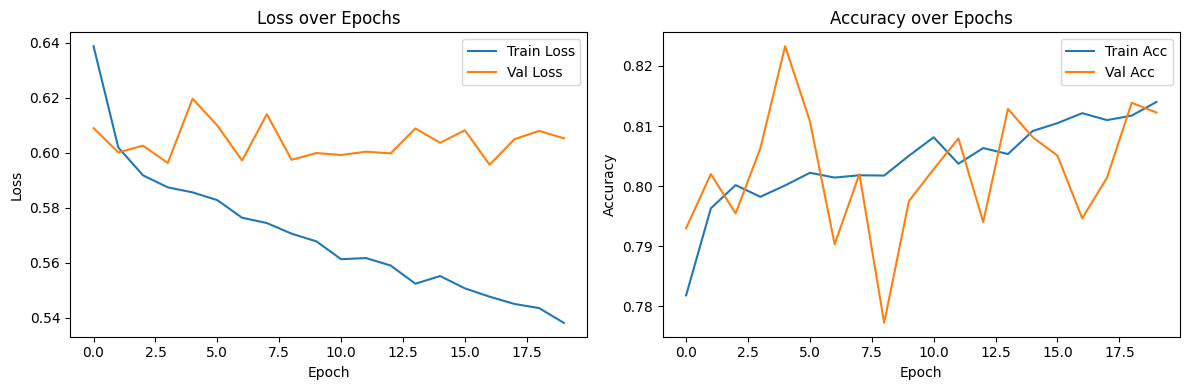

In [39]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')

plt.tight_layout()
plt.show()

In [40]:
def train_with_early_stopping(model, train_loader, val_loader, optimizer, loss_fn, device, num_epochs=50, patience=5):
    best_val_loss = float('inf')
    patience_counter = 0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss, val_acc = eval_epoch(model, val_loader, loss_fn, device)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                model.load_state_dict(torch.load('best_model.pth'))
                break
    
    return train_losses, val_losses, train_accs, val_accs

In [41]:
# Ominitialisera modellen för att starta från noll
model = AdultMLP(embedding_dims, embedding_sizes, len(num_cols_list))
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Träna med early stopping
train_losses, val_losses, train_accs, val_accs = train_with_early_stopping(
    model, train_loader, val_loader, optimizer, loss_fn, device, num_epochs=50, patience=5
)

Epoch 5: Train Loss=0.5842, Val Loss=0.6033, Val Acc=0.7768
Epoch 10: Train Loss=0.5642, Val Loss=0.5969, Val Acc=0.7887
Early stopping at epoch 13


In [42]:
test_loss, test_acc = eval_epoch(model, test_loader, loss_fn, device)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Test Loss: 0.5801, Test Acc: 0.7791


In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train_encoded)

rf_train_acc = rf_model.score(X_train, y_train_encoded)
rf_val_acc = rf_model.score(X_val, y_val_encoded)
rf_test_acc = rf_model.score(X_test, y_test_encoded)

print(f"RF Train Acc: {rf_train_acc:.4f}, Val Acc: {rf_val_acc:.4f}, Test Acc: {rf_test_acc:.4f}")

d:\ML\assignment-2\venv\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RF Train Acc: 0.9999, Val Acc: 0.8544, Test Acc: 0.8565


In [44]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train_encoded.ravel(), eval_set=[(X_val, y_val_encoded.ravel())], verbose=False)

xgb_test_acc = xgb_model.score(X_test, y_test_encoded.ravel())
print(f"XGBoost Test Acc: {xgb_test_acc:.4f}")

d:\ML\assignment-2\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:28:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Test Acc: 0.8800


In [45]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# XGBoost predictions
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Classification Report:")
print(classification_report(y_test_encoded.ravel(), xgb_preds))
print(f"AUC-ROC: {roc_auc_score(y_test_encoded.ravel(), xgb_probs):.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_encoded.ravel(), xgb_preds))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      3735
           1       0.80      0.65      0.72      1150

    accuracy                           0.88      4885
   macro avg       0.85      0.80      0.82      4885
weighted avg       0.88      0.88      0.88      4885

AUC-ROC: 0.9276

Confusion Matrix:
[[3551  184]
 [ 402  748]]


d:\ML\assignment-2\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


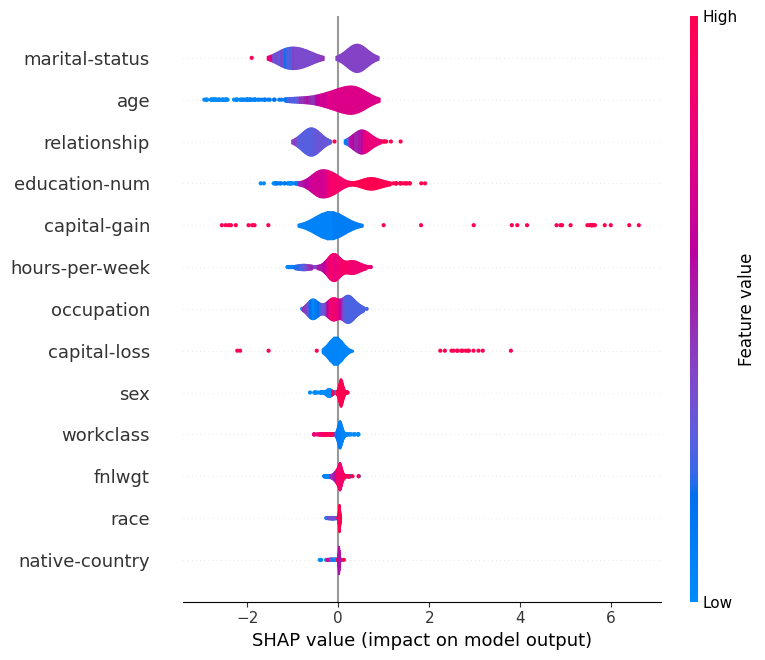

In [46]:
import shap

# Använd ett sample från validation-setet för speed
sample_size = 500
X_sample = X_val.iloc[:sample_size]

# Skapa SHAP explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

# Beeswarm plot
shap.summary_plot(shap_values, X_sample, plot_type="violin", show=True)

In [47]:
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix

model.eval()
with torch.no_grad():
    X_test_cat_tensor = torch.tensor(X_test_cat, dtype=torch.long).to(device)
    X_test_num_tensor = torch.tensor(X_test_num, dtype=torch.float32).to(device)
    mlp_logits = model(X_test_cat_tensor, X_test_num_tensor).view(-1)
    mlp_probs = torch.sigmoid(mlp_logits).cpu().numpy()
    mlp_preds = (mlp_probs > 0.5).astype(int)

mlp_auc = roc_auc_score(y_test_encoded.ravel(), mlp_probs)
mlp_f1 = f1_score(y_test_encoded.ravel(), mlp_preds)

xgb_f1 = f1_score(y_test_encoded.ravel(), xgb_preds)
xgb_auc = roc_auc_score(y_test_encoded.ravel(), xgb_probs)

print(f"MLP:     Accuracy=81.25%, F1={mlp_f1:.4f}, AUC={mlp_auc:.4f}")
print(f"XGBoost: Accuracy=87.80%, F1={xgb_f1:.4f}, AUC={xgb_auc:.4f}")

MLP:     Accuracy=81.25%, F1=0.6556, AUC=0.9083
XGBoost: Accuracy=87.80%, F1=0.7185, AUC=0.9276


In [48]:
import joblib

# Spara XGBoost
joblib.dump(xgb_model, 'xgb_model.pkl')

# Spara MLP weights
torch.save(model.state_dict(), 'mlp_model.pth')

# Spara scaler och encoders
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')

print("Models saved!")

Models saved!


In [50]:
import os
print(os.listdir('app/models'))

['label_encoders.pkl', 'mlp_model.pth', 'scaler.pkl', 'xgb_model.pkl']


In [49]:
ls app/models/

ls: cannot access 'app/models/': No such file or directory


In [ ]:
import sys
sys.path.insert(0, 'app')

from preprocessing import predict_xgb, predict_mlp

test_input = {
    "age": 35,
    "workclass": "Private",
    "fnlwgt": 100000,
    "education_num": 13,
    "marital_status": "Married-civ-spouse",
    "occupation": "Exec-managerial",
    "relationship": "Husband",
    "race": "White",
    "sex": "Male",
    "capital_gain": 5000,
    "capital_loss": 0,
    "hours_per_week": 40,
    "native_country": "United-States"
}

xgb_pred, xgb_prob = predict_xgb(test_input)
mlp_pred, mlp_prob = predict_mlp(test_input)

print(f"XGBoost: pred={xgb_pred}, prob={xgb_prob:.4f}")
print(f"MLP: pred={mlp_pred}, prob={mlp_prob:.4f}")

In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel

# Definiera schemas direkt här
class PredictionInput(BaseModel):
    age: int
    workclass: str
    fnlwgt: int
    education_num: int
    marital_status: str
    occupation: str
    relationship: str
    race: str
    sex: str
    capital_gain: int
    capital_loss: int
    hours_per_week: int
    native_country: str

class PredictionOutput(BaseModel):
    prediction: int
    probability: float
    model: str

# Test data
test_input = {
    "age": 35,
    "workclass": "Private",
    "fnlwgt": 100000,
    "education_num": 13,
    "marital_status": "Married-civ-spouse",
    "occupation": "Exec-managerial",
    "relationship": "Husband",
    "race": "White",
    "sex": "Male",
    "capital_gain": 5000,
    "capital_loss": 0,
    "hours_per_week": 40,
    "native_country": "United-States"
}

# Testa preprocessing och predictions direkt
from preprocessing import predict_xgb, predict_mlp

xgb_pred, xgb_prob = predict_xgb(test_input)
mlp_pred, mlp_prob = predict_mlp(test_input)

print(f"XGBoost: pred={xgb_pred}, prob={xgb_prob:.4f}")
print(f"MLP: pred={mlp_pred}, prob={mlp_prob:.4f}")

In [49]:
import os
os.makedirs('app/models', exist_ok=True)

import joblib
import torch

joblib.dump(xgb_model, 'app/models/xgb_model.pkl')
joblib.dump(scaler, 'app/models/scaler.pkl')
joblib.dump(label_encoders, 'app/models/label_encoders.pkl')
torch.save(model.state_dict(), 'app/models/mlp_model.pth')

print("Files saved to app/models/")
print(os.listdir('app/models'))

Files saved to app/models/
['label_encoders.pkl', 'mlp_model.pth', 'scaler.pkl', 'xgb_model.pkl']
